In [449]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn import linear_model
import pandas as pd
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_validate, cross_val_predict, KFold
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import cross_val_score, cross_val_predict, KFold, StratifiedKFold
!pip install astroML
from astroML.linear_model import LinearRegression, PolynomialRegression, BasisFunctionRegression, NadarayaWatson

In [450]:
data = pd.read_csv('/content/mu_z_data.csv')
data_clean = data.drop(columns=['dmu', 'mu_true'])
X = data_clean['z']
y = data_clean['mu']

Text(0.5, 1.0, 'Data')

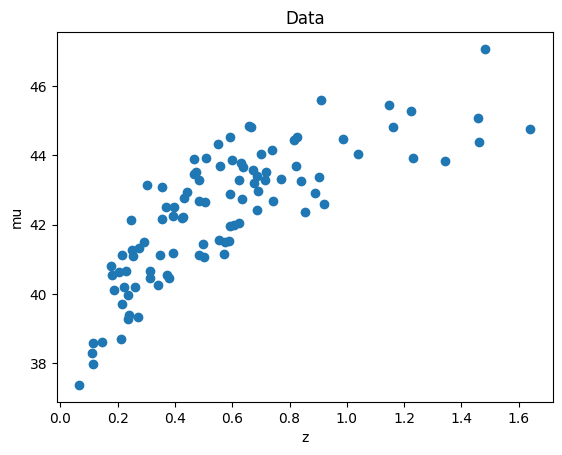

In [451]:
plt.scatter(X,y)
plt.xlabel('z')
plt.ylabel('mu')
plt.title('Data')

Guassian kernel regression

In [452]:
nmodel = NadarayaWatson('gaussian', 0.05) # Gaussian kernel with bandwidth 0.05
nmodel.fit(X.values.reshape(-1,1), y)
ypred1 = nmodel.predict(X.values.reshape(-1,1))

In [453]:
nmodel.fit(X.values.reshape(-1,1), y)
ypred1 = nmodel.predict(X.values.reshape(-1,1))

In [454]:
nmodel.get_params()

{'h': 0.05, 'kernel': 'gaussian'}

In [455]:
ypred1

array([42.76607345, 43.48056604, 43.0586901 , 42.75144845, 42.59275743,
       43.31689703, 42.61562439, 44.2377522 , 44.05822841, 42.44053997,
       43.59139774, 42.70246946, 42.85227278, 44.9963659 , 40.10805321,
       40.24801656, 38.91237126, 43.60625327, 43.6178717 , 44.01349669,
       45.55039147, 43.57430997, 42.63319723, 43.61458987, 40.44504393,
       43.28715879, 40.60421349, 44.69108398, 42.68606749, 42.5707568 ,
       41.56384531, 43.62141467, 42.6307989 , 42.85426086, 38.85541875,
       43.15544165, 43.11961983, 43.15094027, 44.71065604, 43.43033298,
       42.28556732, 42.61493729, 43.4537186 , 39.97516485, 43.39605586,
       43.40648737, 41.14218304, 40.5101785 , 41.94118938, 42.31558587,
       42.86337526, 42.61683724, 44.78754295, 40.34721302, 41.12942633,
       40.73402375, 43.3487264 , 41.48185887, 42.63500404, 41.41573925,
       40.71626573, 40.39774209, 43.3614184 , 40.56955693, 41.02439831,
       42.35001097, 43.56503827, 40.31609635, 43.63848813, 40.30

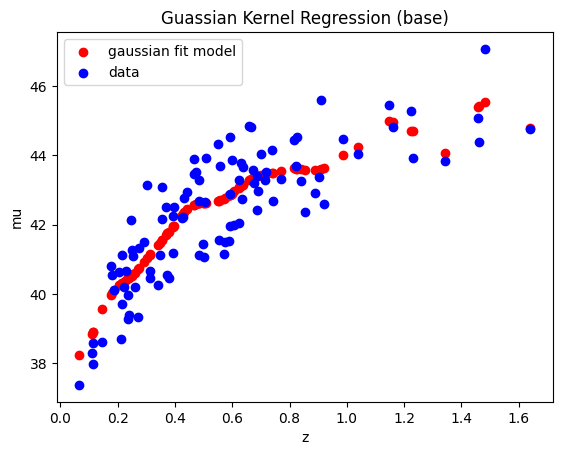

In [456]:
plt.scatter(X,ypred1,label = "gaussian fit model" , c = "red")
plt.scatter(X,y, label = 'data', c = 'blue')
plt.xlabel('z')
plt.ylabel('mu')
plt.title('Guassian Kernel Regression (base)')
plt.legend()
plt.show()


Gaussian basis funstion regression

In [457]:
mu = np.linspace(0, 1, 10)[:, np.newaxis] # 10x1 array of mu
sigma = 0.1
gmodel = BasisFunctionRegression('gaussian', mu=mu, sigma=sigma)
gmodel.fit(X.values.reshape(-1,1), y)
ypred2 = gmodel.predict(X.values.reshape(-1,1))

In [458]:
gmodel.get_params()


{'basis_func': 'gaussian',
 'fit_intercept': True,
 'kwds': None,
 'regularization': 'none'}

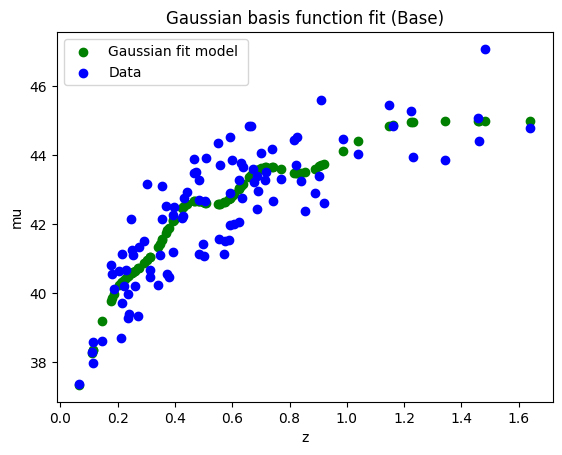

In [459]:
plt.scatter(X,ypred2, label = 'Gaussian fit model ', c = 'green')
plt.scatter(X,y, label = 'Data', c = 'blue')
plt.xlabel('z')
plt.ylabel('mu')
plt.legend()
plt.title('Gaussian basis function fit (Base)')
plt.show()

Doing a bench mark learning curve for the guassian basis function
(had to use sklearn's gaussian process because the astro ML gaussain process was not working with the learning curve)

In [460]:
from sklearn.model_selection import LearningCurveDisplay, ShuffleSplit
import sklearn.gaussian_process as gp

In [461]:
gmod = make_pipeline(
    RobustScaler(),
    gp.GaussianProcessRegressor(alpha=1e-12, random_state=0)
)
gmod.fit(X.values.reshape(-1,1),y)
ypred3 = gmod.predict(X.values.reshape(-1,1))

Text(0.5, 1.0, 'Bench mark fit ')

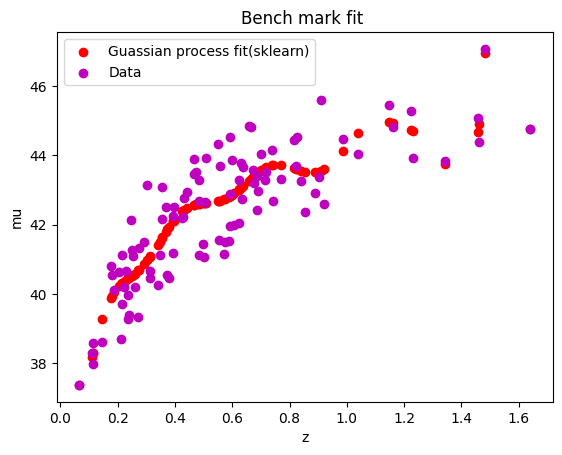

In [462]:
plt.scatter(X,ypred3, c = 'r', label = 'Guassian process fit(sklearn)')
plt.scatter(X,y, c = 'm', label = 'Data')
plt.xlabel('z')
plt.ylabel('mu')
plt.legend()
plt.title('Bench mark fit ')

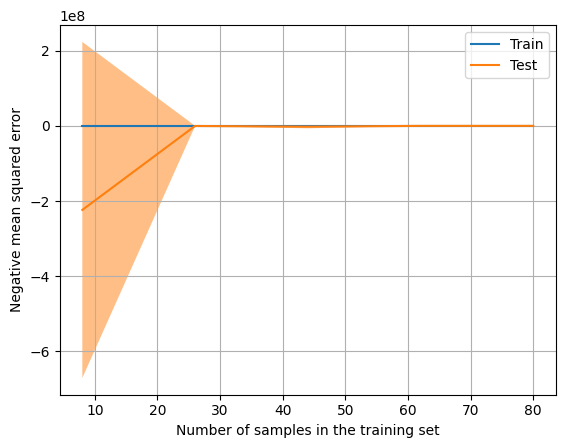

In [511]:
LearningCurveDisplay.from_estimator(
    gmod, X.values.reshape(-1,1), y,
    cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0),
    scoring="neg_mean_squared_error",
    shuffle=True,
    random_state=0,
)
plt.grid()


In [500]:
from sklearn.model_selection import GridSearchCV

In [501]:
parameters = { 'gaussianprocessregressor__alpha': [1e-12,1e-6, 1e-4, 1e-3,1e-2,1e-1,1,2,10]}


In [502]:
model = GridSearchCV(gmod, parameters, scoring = 'neg_mean_squared_error', cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0),
                     verbose = 2, n_jobs = 4, return_train_score=True)
model.fit(X.values.reshape(-1,1), y)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


GridSearchCV(cv=ShuffleSplit(n_splits=5, random_state=0, test_size=0.2, train_size=None),
             estimator=Pipeline(steps=[('robustscaler', RobustScaler()),
                                       ('gaussianprocessregressor',
                                        GaussianProcessRegressor(alpha=1e-12,
                                                                 random_state=0))]),
             n_jobs=4,
             param_grid={'gaussianprocessregressor__alpha': [1e-12, 1e-06,
                                                             0.0001, 0.001,
                                                             0.01, 0.1, 1, 2,
                                                             10]},
             return_train_score=True, scoring='neg_mean_squared_error',
             verbose=2)

In [503]:
print('Best params, best score:', "{:.4f}".format(model.best_score_), model.best_params_)

Best params, best score: -1.0728 {'gaussianprocessregressor__alpha': 0.01}


In [504]:
gmod_new= make_pipeline(
    RobustScaler(),
    gp.GaussianProcessRegressor(alpha=0.01, random_state=0)
)
gmod.fit(X.values.reshape(-1,1),y)
ypred3 = gmod.predict(X.values.reshape(-1,1))

In [509]:
model = GridSearchCV(gmod_new, parameters, scoring = "neg_mean_squared_error", cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0),
                     verbose = 2, n_jobs = 4, return_train_score=True)
model.fit(X.values.reshape(-1,1), y)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


GridSearchCV(cv=ShuffleSplit(n_splits=5, random_state=0, test_size=0.2, train_size=None),
             estimator=Pipeline(steps=[('robustscaler', RobustScaler()),
                                       ('gaussianprocessregressor',
                                        GaussianProcessRegressor(alpha=0.01,
                                                                 random_state=0))]),
             n_jobs=4,
             param_grid={'gaussianprocessregressor__alpha': [1e-12, 1e-06,
                                                             0.0001, 0.001,
                                                             0.01, 0.1, 1, 2,
                                                             10]},
             return_train_score=True, scoring='neg_mean_squared_error',
             verbose=2)

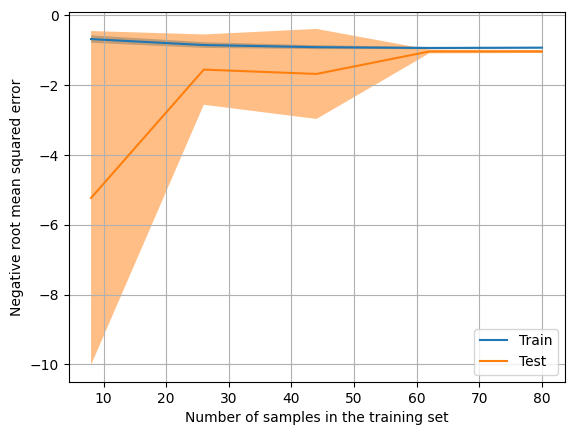

In [510]:
LearningCurveDisplay.from_estimator(
    gmod_new, X.values.reshape(-1,1), y,
    cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0),
    scoring="neg_root_mean_squared_error",
    shuffle=True,
    random_state=0,
)
plt.grid()

I think that there is something off about how the learning curves are displayed, but based on the fact that the grid search returned a value of alpha that was greater. It seems like our model needed to be more complex.